In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import figure
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('data/maintenance/predictive_maintenance.csv')
df.head(3)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure


### Basic info about the dataset

In [3]:
df.shape

(10000, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [6]:
print(df.duplicated().sum())

0


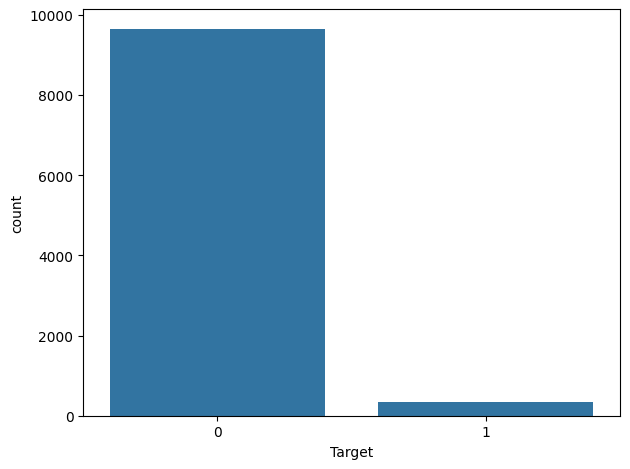

In [7]:
sns.countplot(data=df, x=df["Target"])
plt.tight_layout()
plt.show()

### Dropping unnecessary columns
Also dropping Failure Type, because it is highly correlated with the target variable, which can lead to data leakage

In [8]:
df = df.drop(columns=["UDI", "Product ID", "Failure Type"])

### Encoding Categorical atribute `Type`

In [9]:
for column in df.columns:
    if df[column].dtype == "str":
        print(df[column].unique())

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str


In [10]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [11]:
pd.get_dummies(df['Type']).columns

Index(['H', 'L', 'M'], dtype='str')

In [12]:
df =  pd.get_dummies(df, drop_first=False)
df

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,False,True
1,298.2,308.7,1408,46.3,3,0,False,True,False
2,298.1,308.5,1498,49.4,5,0,False,True,False
3,298.2,308.6,1433,39.5,7,0,False,True,False
4,298.2,308.7,1408,40.0,9,0,False,True,False
...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,False,False,True
9996,298.9,308.4,1632,31.8,17,0,True,False,False
9997,299.0,308.6,1645,33.4,22,0,False,False,True
9998,299.0,308.7,1408,48.5,25,0,True,False,False


### Correlation Matrix

<Axes: >

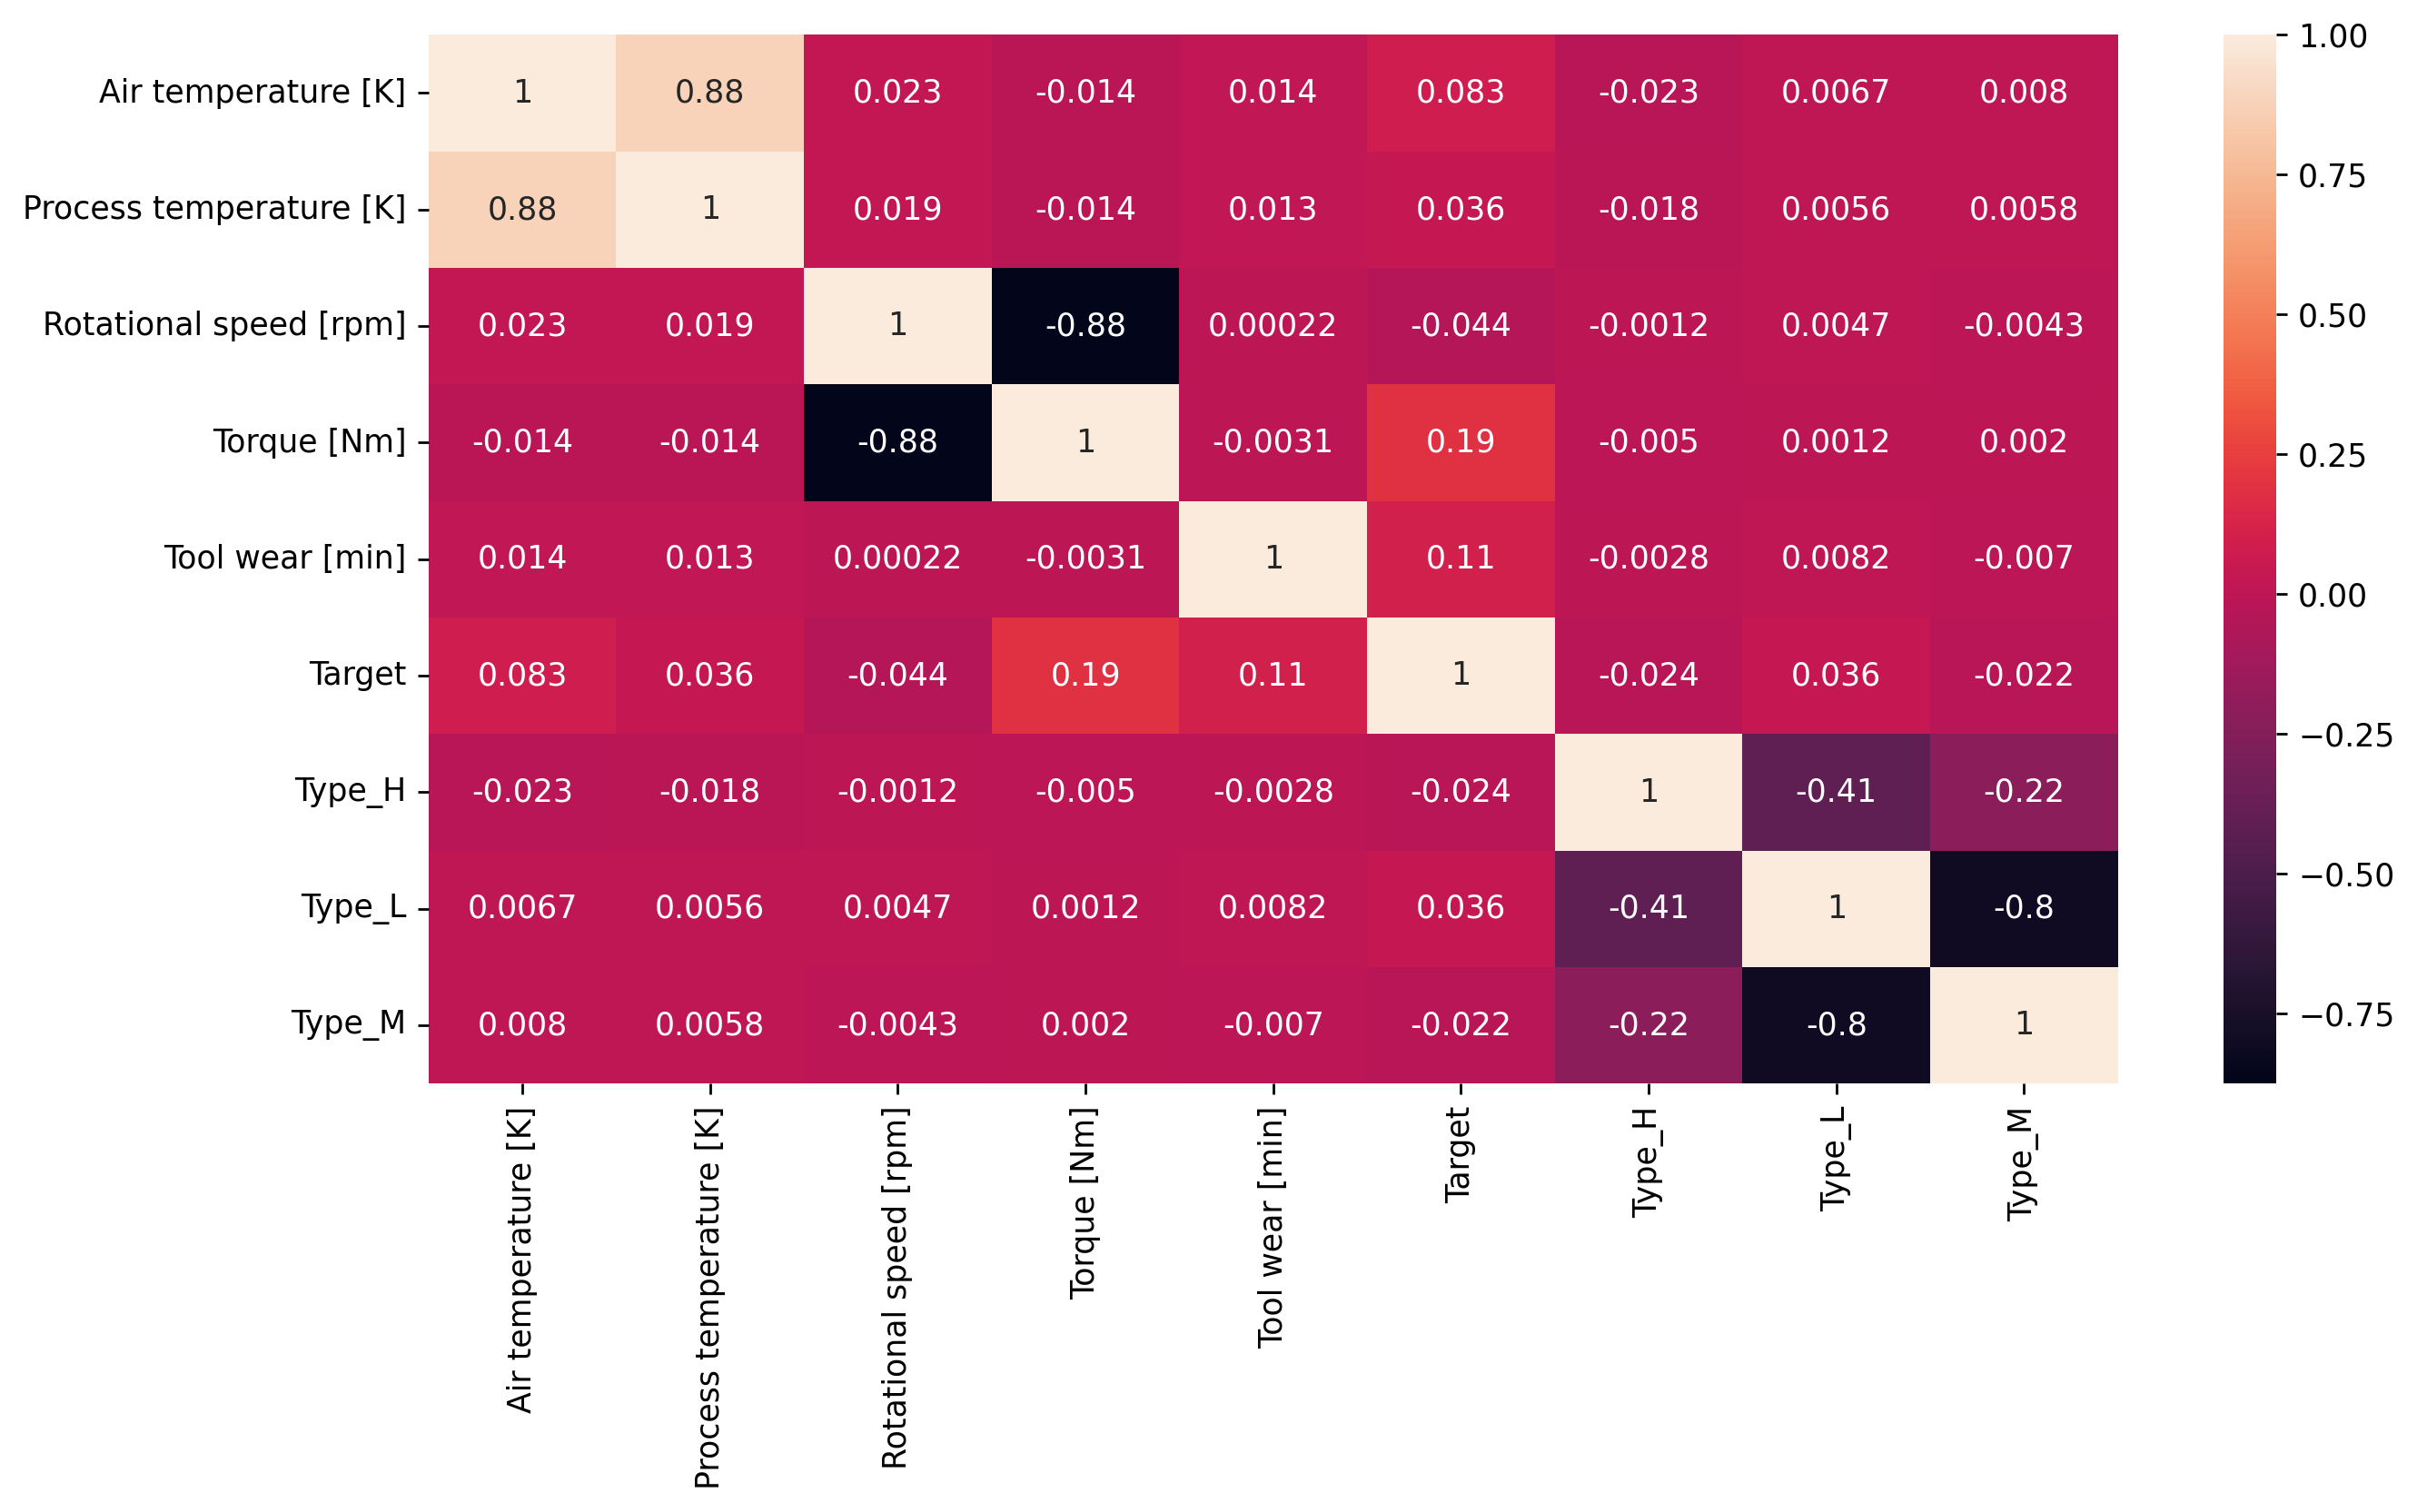

In [13]:
corr = df.corr()
figure(figsize=(12, 6), dpi=250)
sns.heatmap(corr, annot=True)

### Dropping attributes with high correlation between each other

In [14]:
df.drop(["Air temperature [K]", "Torque [Nm]"], axis=1)

,Process temperature [K],Rotational speed [rpm],Tool wear [min],Target,Type_H,Type_L,Type_M
0,308.6,1551,0,0,False,False,True
1,308.7,1408,3,0,False,True,False
2,308.5,1498,5,0,False,True,False
3,308.6,1433,7,0,False,True,False
4,308.7,1408,9,0,False,True,False
...,...,...,...,...,...,...,...
9995,308.4,1604,14,0,False,False,True
9996,308.4,1632,17,0,True,False,False
9997,308.6,1645,22,0,False,False,True
9998,308.7,1408,25,0,True,False,False


In [15]:
X = df.drop("Target", axis=1)
y = df["Target"]

### Splitting the dataset into training and testing sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=42, 
                                                    test_size=0.25, 
                                                    shuffle=True)

### Data scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Oversampling the minority class using SMOTE technique

In [18]:
sm = SMOTEENN(random_state=42, sampling_strategy=0.7)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

### Model testing and evaluation

In [19]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoost": GradientBoostingClassifier()
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred_model = model.predict(X_test_scaled)
    predictions[name] = y_pred_model

    report = classification_report(y_test, y_pred_model, output_dict=True, zero_division=0)
    results.append({
        'Model': name,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-score': report['1']['f1-score']
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1-score
0,LogReg,0.139423,0.805556,0.237705
1,KNN,0.231405,0.777778,0.356688
2,DecisionTree,0.323864,0.791667,0.459677
3,RandomForest,0.371069,0.819444,0.510823
4,GradientBoost,0.294931,0.888889,0.442907


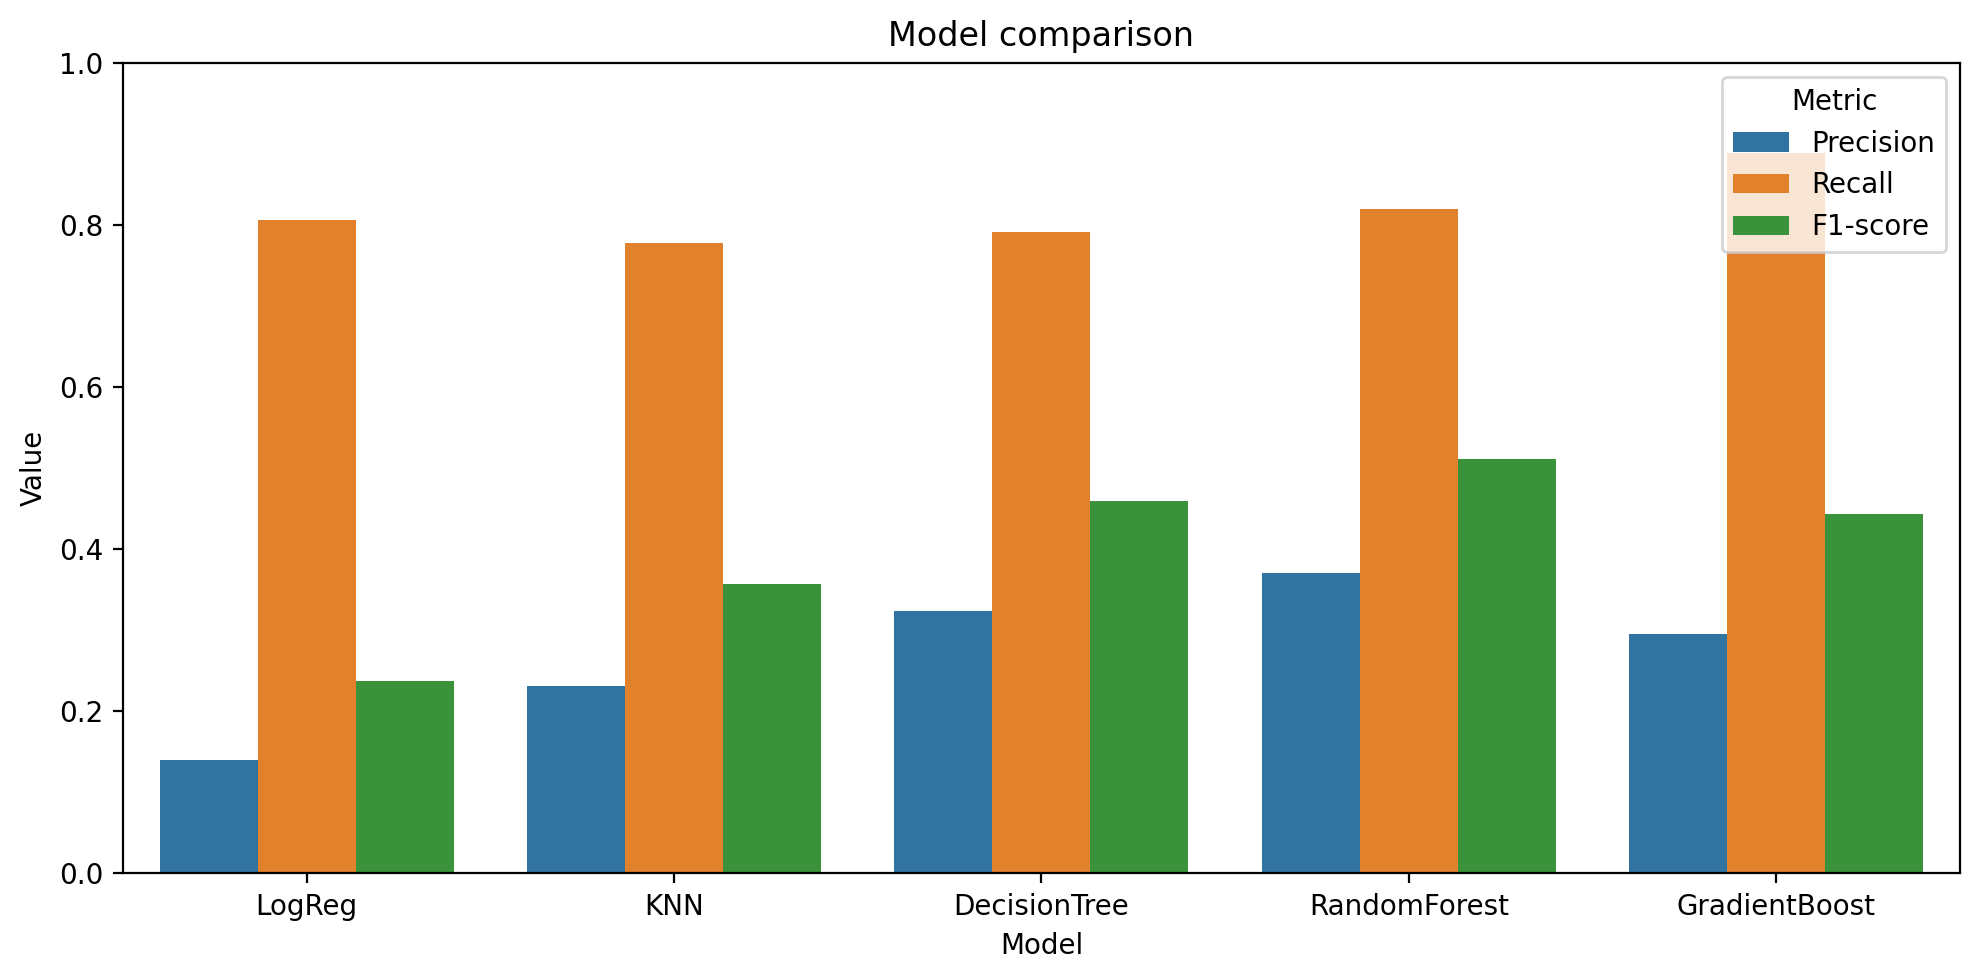

In [20]:
metrics = results_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 5), dpi=200)
sns.barplot(data=metrics, x='Model', y='Value', hue='Metric')
plt.ylim(0, 1)
plt.title('Model comparison')
plt.tight_layout()
plt.show()